In [1]:
import gymnasium as gym

import matplotlib.pyplot as plt

import torch.fft as fft
from stable_baselines3 import DQN

import pywaspgen


%load_ext autoreload
%autoreload 2

In [7]:
import rfrl_gym
import numpy as np
import math

In [5]:
def gen_states(self, channels=10, emitters=3, num_states=10, seed=3):
    states = set() # empty set to hold states
    rng = np.random.default_rng(seed=seed)
    # combinotoric check
    assert num_states <= math.comb(channels, emitters), f'Error: For {channels} channels and {emitters}\
     emitters there are only {math.comb(channels, emitters)} unique states\
      to choose from given deterministic transitions with no repeating states.'
    while len(states) < num_states:
        # IF non deterministic we don't have to check for duplicates -- should develop method for controlled Stochasticity
        idx = tuple(sorted(rng.choice(range(channels), size=emitters, replace=False)))
        states.add(idx) # sorting + set ensuring uniqueness

    #channel occupancy map (cop)
    cop = np.zeros((num_states, channels))
    idx=0
    for state in states:
        cop[idx][np.array(state)]=1
        idx += 1
    return cop

In [13]:
states = gen_states(None, channels=5, num_states=5, seed=3)

In [15]:
states[0]

array([1., 0., 1., 0., 1.])

In [8]:
import sys
print(sys.executable)

/home/sleathers/PycharmProjects/rfrl/.venv/bin/python


In [6]:
import torch

In [7]:
torch.cuda.is_available()

True

In [24]:
fc = np.linspace(-0.5, 0.5, 10)+1/10/2

In [30]:
np.linspace(-0.5, 0.5, 10)+1/10/2

array([-0.45      , -0.33888889, -0.22777778, -0.11666667, -0.00555556,
        0.10555556,  0.21666667,  0.32777778,  0.43888889,  0.55      ])

In [22]:
fft.fftfreq(100)

tensor([ 0.0000,  0.0100,  0.0200,  0.0300,  0.0400,  0.0500,  0.0600,  0.0700,
         0.0800,  0.0900,  0.1000,  0.1100,  0.1200,  0.1300,  0.1400,  0.1500,
         0.1600,  0.1700,  0.1800,  0.1900,  0.2000,  0.2100,  0.2200,  0.2300,
         0.2400,  0.2500,  0.2600,  0.2700,  0.2800,  0.2900,  0.3000,  0.3100,
         0.3200,  0.3300,  0.3400,  0.3500,  0.3600,  0.3700,  0.3800,  0.3900,
         0.4000,  0.4100,  0.4200,  0.4300,  0.4400,  0.4500,  0.4600,  0.4700,
         0.4800,  0.4900, -0.5000, -0.4900, -0.4800, -0.4700, -0.4600, -0.4500,
        -0.4400, -0.4300, -0.4200, -0.4100, -0.4000, -0.3900, -0.3800, -0.3700,
        -0.3600, -0.3500, -0.3400, -0.3300, -0.3200, -0.3100, -0.3000, -0.2900,
        -0.2800, -0.2700, -0.2600, -0.2500, -0.2400, -0.2300, -0.2200, -0.2100,
        -0.2000, -0.1900, -0.1800, -0.1700, -0.1600, -0.1500, -0.1400, -0.1300,
        -0.1200, -0.1100, -0.1000, -0.0900, -0.0800, -0.0700, -0.0600, -0.0500,
        -0.0400, -0.0300, -0.0200, -0.01

In [2]:
2.0*(5==2)

0.0

In [25]:
fc

array([-0.45      , -0.33888889, -0.22777778, -0.11666667, -0.00555556,
        0.10555556,  0.21666667,  0.32777778,  0.43888889,  0.55      ])

In [8]:
s = gym.spaces.Discrete(1+10)

In [16]:
vals = set()
for i in range(1000):
    val = s.sample()
    vals.add(val)

In [17]:
vals

{np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10)}

In [2]:
# intilize environment through gym, specifying our scenario json
env = gym.make('rfrl-gym-iq-v0.1', scenario_filename='sb3_test_scenario.json',
               pywasp_config = "pywaspgen/configs/default.json",
               num_episodes=10)


In [3]:
env.reset()

4 4


(0, {})

In [4]:
env.step(1)

4 4


/home/sleathers/anaconda3/envs/rfrl_dev/lib/python3.14/site-packages/gymnasium/utils/passive_env_checker.py:126: UserWarning: WARN: The obs returned by the `step()` method should be an int or np.int64, actual type: <class 'numpy.ndarray'>
  logger.warn(f"{pre} should be an int or np.int64, actual type: {type(obs)}")
/home/sleathers/anaconda3/envs/rfrl_dev/lib/python3.14/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


(array([-0.02908384-0.97962475j,  1.19669391+0.54639303j,
        -0.40216038+0.77517756j, ...,  0.18597514-0.04397534j,
        -2.28121032+1.24593896j,  0.60766113+0.75362155j], shape=(10000,)),
 np.float64(-1.0),
 False,
 False,
 {'step_number': 1,
  'num_entities': 4,
  'num_episodes': 10,
  'episode_reward': array([], dtype=float64),
  'episode_number': 0,
  'action_history': {'user_agent': array([-1,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]),
   'constant_freq_1': array([ 0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1,

In [10]:
env.unwrapped.info['spectrum_data'].min()

np.complex128(-30.450168381548053+1.712438543540185j)

In [18]:
env.unwrapped.info['spectrum_data'].imag.min()

np.float64(-29.577744758627937)

In [9]:
vars(env.unwrapped.observation_space)

{'n': np.int64(1024),
 'start': np.int64(0),
 '_shape': (),
 'dtype': dtype('int64'),
 '_np_random': None}

In [10]:
env.unwrapped.observation_space.n

np.int64(1024)

In [ ]:
class DSARewardWrapper(gym.RewardWrapper):
    def __init__(self, env, some_metric = None):
        super().__init__(env)
        self.some_metric = some_metric
        
    def reward(self, action) -> float:
        # reward if our action stepped into a bin that was not occupied
        if action == -1:
            reward = 0
        else: 
            reward = 2.0*int(self.info['true_history'][self.info['step_number']][action]==0)-1.0
        self.info['reward_history'][self.info['step_number']] = reward
        return reward

In [ ]:
# Calculate the player reward.
    reward = self.reward(action)
        
### outside of step -- Env class method
def reward(self, action):
    # jam reward 
    if action == -1:
        reward = 0
    else: 
        reward = 2.0*int(self.info['true_history'][self.info['step_number']][action]==self.target_idx)-1.0
    # handles info logic inside of method
    self.info['reward_history'][self.info['step_number']] = reward
    return reward

In [ ]:
def step(self, action):
    # update base environment info
    self.info['step_number'] += 1
    self.info['action_history'][0][self.info['step_number']] = action
    # step observations -- handles detector sensing results and observation
    observation = self.observation()
    # generate IQ data/ handles entities
    self.info['spectrum_data'] = self.iq_gen.gen_iq(self.info['action_history'][:,self.info['step_number']])
    # Calculate the player reward.
    reward = self.reward(action)
    return int(observation), reward, done, done, self.info

In [15]:
class InfoAccessWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        # Define the new observation space if your wrapper modifies it.
        # For this example, let's assume we add a scalar from info to the observation.
        # Original observation space is (2,) for agent_position and target_position.
        # We'll add one more dimension for a value from info.
        original_obs_space_shape = self.observation_space.n
        print(original_obs_space_shape)
        new_obs_shape = (original_obs_space_shape + 1,)
        #self.observation_space = Box(low=-np.inf, high=np.inf, shape=new_obs_shape, dtype=np.float32)
        #print(self.env.info)
        
    def observation(self, obs):
        # Access the info dictionary from the wrapped environment.
        # Note: You can't directly access 'info' in the observation method itself,
        # as 'info' is returned alongside 'obs' by env.step() or env.reset().
        # To incorporate info into the observation, you'd typically need to
        # modify the 'step' method of a custom Wrapper (not just ObservationWrapper)
        # or have the environment itself include relevant info in its observation.

        # However, if the info you need is *always* available as an attribute
        # of the *environment itself* (e.g., self.env.some_info_attribute),
        # then you can access it here. Let's assume for this example
        # that the environment has a 'current_step' attribute we want to add.
        # This is a common pattern for adding persistent environment state to observations.

        # Example: Add a hypothetical 'current_step_count' from the environment to the observation
        # Assuming the base environment has an attribute called 'current_step_count'
        # If your environment doesn't have such an attribute, this will raise an AttributeError.
        try:
            step_info = np.array([self.env.current_step_count], dtype=np.float32)
        except AttributeError:
            print("Warning: 'current_step_count' not found in environment. Adding zero instead.")
            step_info = np.array([0.0], dtype=np.float32)

        # Concatenate the original observation with the info-derived value
        new_obs = np.concatenate((obs, step_info))
        return new_obs

In [16]:
tmp = InfoAccessWrapper(env)

1024


In [17]:
vars(tmp)

{'env': <TimeLimit<OrderEnforcing<PassiveEnvChecker<RFRLGymIQEnv<rfrl-gym-iq-v0>>>>>,
 '_action_space': None,
 '_observation_space': None,
 '_metadata': None,
 '_cached_spec': None}

In [19]:
tmp.env.unwrapped.info

{'step_number': 0,
 'num_entities': 4,
 'num_episodes': 10,
 'episode_reward': array([], dtype=float64),
 'episode_number': 0,
 'action_history': array([[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 9, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 6, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]]),
 'true_history': array([[5, 0, 0, 0, 0, 0, 3, 0, 0, 2],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  

In [6]:
# instantiate model with env
model = DQN("MlpPolicy", env, verbose=1, exploration_initial_eps=1.0, exploration_final_eps=0.001,exploration_fraction=0.995)
epochs = 1

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [5]:
# for _ in range(args.epochs):
model = model.learn(total_timesteps=env.unwrapped.max_steps * epochs,
                    log_interval=1,
                    progress_bar=True,
                   reset_num_timesteps=True)


 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31/30  [ 0:00:08 < 0:00:00 , 4 it/s ]

In [14]:
obs, info = env.reset()
terminated = truncated= False
running_reward = 0
rewards = []
step = 0
while not terminated and not truncated:
    step += 1
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    #env.render()
    print(reward)
    print(env.unwrapped.info['spectrum_data'],env.unwrapped.info['spectrum_data'].shape)
    if step > 5:
        break

-1.0
[-0.23086529+0.0243395j  -1.17278322+0.75347287j  0.52226691+0.74148328j
 ...  0.40683796+0.04311516j -0.29006261+0.76883842j
 -0.24536516-0.78387226j] (400000,)
1.0
[-0.31894436-0.03509928j -0.24417593-0.97247472j -1.49975379-0.90786077j
 ... -0.13985859-0.00661723j  0.25094845+0.67996015j
  0.21303662-0.31945582j] (400000,)
1.0
[-0.17153862-0.54656192j  1.66041883+0.61313668j -1.93982995-0.82886326j
 ... -0.43951194-0.93876588j -0.1229601 -0.98621464j
 -0.42288541-0.87764865j] (400000,)
1.0
[-0.47760622+0.32449839j -1.26019377-1.01167413j -1.57820491+1.27476881j
 ...  0.26874024+0.00942704j -0.75280813+0.58487932j
 -0.1712027 -0.60586985j] (400000,)
1.0
[-0.37523442-1.65586784j -0.17224157-0.34647302j  0.90863687+0.95882113j
 ...  0.2865342 +0.25677933j  0.60801024+0.49334892j
  0.11460241+0.49368703j] (400000,)
-1.0
[ 0.44268202+0.98856563j -0.23469696+0.02304032j -0.28049881+0.95340132j
 ...  0.64198362+0.32470472j  0.81065318+0.53464866j
  0.23330819+0.40395864j] (400000,)


In [23]:
env.unwrapped.fc

array([-0.45, -0.35, -0.25, -0.15, -0.05,  0.05,  0.15,  0.25,  0.35,
        0.45,  0.55])

In [47]:
d = np.array([env.unwrapped.info['spectrum_data'],env.unwrapped.info['spectrum_data']])

In [49]:
d.nbytes *1e-9

0.0128

In [51]:
np.tile(env.unwrapped.info['spectrum_data'], 1000).nbytes* 1e-9

6.4

In [7]:
env.unwrapped.scenario_metadata['environment']['num_channels']

10

In [17]:
env.unwrapped.scenario_metadata['entities'][entity]

{'type': 'ConstantFreq',
 'channels': [0],
 'onoff': [1, 1, 0],
 'modem_params': {'type': 'qam',
  'order': 16,
  'filter': 'RRC',
  'center_frequency': [-0.1, 0.1],
  'bandwidth': 0.25,
  'start': 0.25,
  'duration': 0.25}}

In [9]:
env.unwrapped.scenario_metadata['entities'][entity]

{'type': 'ConstantFreq',
 'channels': [0],
 'onoff': [1, 1, 0],
 'modem_params': {'type': 'qam',
  'order': 16,
  'filter': 'RRC',
  'center_frequency': [-0.1, 0.1],
  'bandwidth': 0.25,
  'start': 0.25,
  'duration': 0.25}}

In [35]:
np.linspace(-0.5, 0.5, num_channels+1)+1/num_channels/2

array([-0.45, -0.35, -0.25, -0.15, -0.05,  0.05,  0.15,  0.25,  0.35,
        0.45,  0.55])

In [11]:
r = 'r+'

In [14]:
if 'r' != r:
    print(True)

True


In [37]:
import numpy.fft as fft

In [40]:
fft.fftshift(fft.fftfreq(num_channels))

array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4])

In [ ]:
env.unwrapped.scenario_metadata['entities'][entity]

In [26]:
import json

In [31]:
with open("pywaspgen/configs/default.json", 'r') as config:
    instance = json.load(config)
    samples_per_step = instance['spectrum']['observation_duration']

In [29]:
instance['spectrum']['observation_duration']

10000

In [5]:
env.unwrapped.entity_list

In [6]:
env.unwrapped.user_burst_list

[[
  UUID: 9e5d262b-7d64-4c38-88f1-eaa4d1718c40 - 16qam burst with center frequency: -0.459, bandwidth: 0.025, start time: 2500, duration: 2500, and metadata: {'UUID': UUID('9e5d262b-7d64-4c38-88f1-eaa4d1718c40'), 'snr': 27.14462758896961, 'pulse_type': {'sps': 54.0, 'format': 'RRC', 'params': {'beta': 0.35, 'span': np.int64(10), 'window': ('kaiser', 5)}}, 'modem': <pywaspgen.modem.digital.ldapm.qam.QAM object at 0x7ffa6d2ac830>},
  
  UUID: 315970ac-b0c4-449b-a7ab-d3565589d13e - 4psk burst with center frequency: 0.445, bandwidth: 0.050, start time: 5000, duration: 2500, and metadata: {'UUID': UUID('315970ac-b0c4-449b-a7ab-d3565589d13e'), 'snr': 18.298350763892245, 'pulse_type': {'sps': 27.0, 'format': 'RRC', 'params': {'beta': 0.35, 'span': np.int64(10), 'window': ('kaiser', 5)}}, 'modem': <pywaspgen.modem.digital.ldapm.psk.PSK object at 0x7ffa6d2acad0>},
  
  UUID: 69f84c04-702e-4834-be0e-f99881e920b7 - 4ask burst with center frequency: 0.350, bandwidth: 0.100, start time: 0, duratio

In [4]:
iq_gen = pywaspgen.IQDatagen("pywaspgen/configs/default.json")
burst_gen = pywaspgen.BurstDatagen("pywaspgen/configs/default.json")

In [5]:
iq_data, updated_burst_list = iq_gen.gen_iqdata(env.unwrapped.user_burst_list)

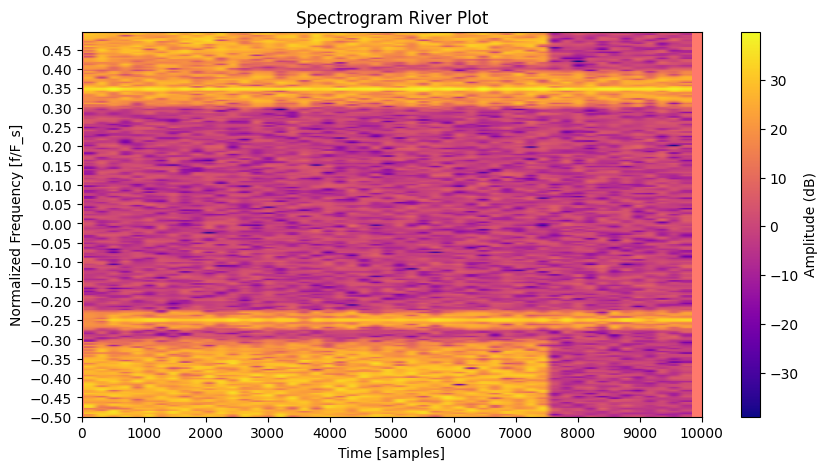

In [6]:
iq_gen.plot_iqdata(iq_data[0])
plt.show()

### Need a function to take in the entity_list and spit out the entire burst_list for the entire run

Considerations: Deterministic vs non deterministic hopping behavior (do all deterministic behavior at start, then non-d on step)

Ensure we are aliasing into the correct bins. 

Consider a cache of signal data if the num_steps*samples_per_step reaches some cache limit

THe render scripts are problematic/ need to be considered when formating data for the run. (render history createa multiple of noise for the pyqt render)


In [15]:
for entity in env.unwrapped.entity_list:
    print(entity, vars(entity)['channels'])

<rfrl_gym.entities.constant_freq.ConstantFreq object at 0x7ffb95a39550> [0]
<rfrl_gym.entities.constant_freq.ConstantFreq object at 0x7ffa6d3c56d0> [9]
<rfrl_gym.entities.fixed_hop_freq.FixedHopFreq object at 0x7ffb95d88ad0> [6, 7, 8, 9, 5]
<rfrl_gym.entities.fixed_hop_freq.FixedHopFreq object at 0x7ffa6d3c5450> [2, 1, 1, 2, 0, 0, 3, 4, 3]


In [16]:
channel = 0
for entity in env.unwrapped.entity_list:
    print(entity.channels)
    print(channel % len(entity.channels))
    channel_index = channel % len(entity.channels)
    print(entity.channels[channel_index])
    channel += 1

[0]
0
0
[9]
0
9
[6, 7, 8, 9, 5]
2
8
[2, 1, 1, 2, 0, 0, 3, 4, 3]
3
2


AttributeError: 'list' object has no attribute 'sig_type'

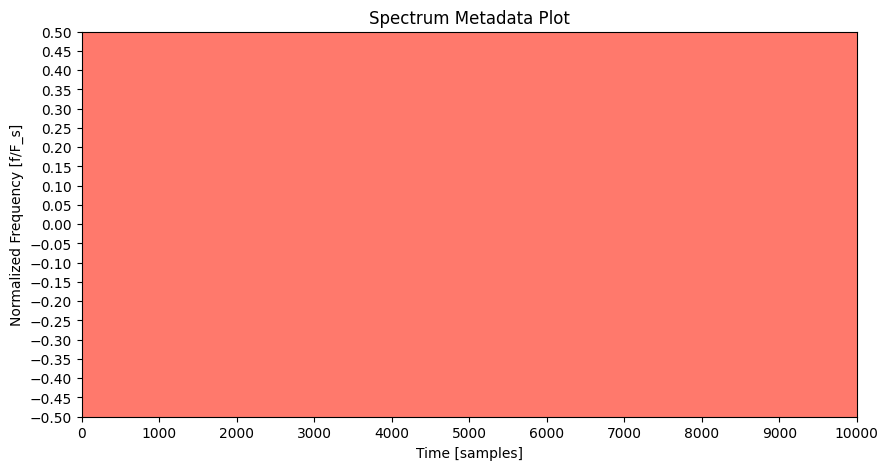

In [11]:
ax = burst_gen.plot_burstdata(updated_burst_list)

### Determine if stochastic entitites are deterministic with seed, and what scope seed is needed

In [9]:
scf = rfrl_gym.entities.StochasticConstantFreq('tmp', num_channels= 10, channels = [0], percent_on=0.5)

In [10]:
scf.channels

[0]

In [24]:
walk42 = []
np.random.seed(42)

In [25]:
for i in range(1000):
    walk42.append(scf._get_action())
    

In [26]:
walk42 == walk422

True

In [28]:
# Generate a random array of length 8
random_array = np.random.rand(8)

# Normalize the array so its elements sum to 1
probabilities = random_array / random_array.sum()

In [30]:
probabilities.sum()

np.float64(1.0)

In [34]:
len(probabilities) == 1

False

In [35]:
g = []

In [40]:
np.random.uniform(low=0, high=1, size=8)

array([0.94426649, 0.47421422, 0.86204265, 0.8445494 , 0.31910047,
       0.82891547, 0.03700763, 0.59626988])

In [32]:
probabilities == []

ValueError: operands could not be broadcast together with shapes (8,) (0,) 

In [41]:
v = [0,1,2,3,4,5,6,7]

In [46]:
o = np.random.choice(v, 80000, p=None)

In [47]:
for i in range(8):
    print((o==i).sum())

9882
10029
9834
10045
10083
10057
10105
9965


In [48]:
shf = rfrl_gym.entities.StochasticHopFreq('tmp', num_channels= 10, channels = [0, 1, 2, 3, 4, 5, 6, 7], channel_weights=probabilities)

In [50]:
walk33 = []
np.random.seed(33)

In [51]:
for i in range(100000):
    walk33.append(shf._get_action())

AttributeError: 'StochasticHopFreq' object has no attribute 'on_flag'

### Need to check the shuffle of channels in hop modes with randhop adheres to global seed